In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv('Data/BTC_historical_INR.csv',index_col='Date',parse_dates=True)
df = df.asfreq('D')   # Daily frequency

In [3]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2021-01-22,91.533478,91.703496,91.488249,91.679604,121548669235
2021-01-23,91.680696,91.730596,91.599952,91.606817,80722167203
2021-01-24,91.606817,91.842293,91.581266,91.685738,84413124756
2021-01-25,91.689122,91.745516,91.524048,91.553342,101158851200
2021-01-26,91.551694,91.723185,91.548311,91.654971,101647526020


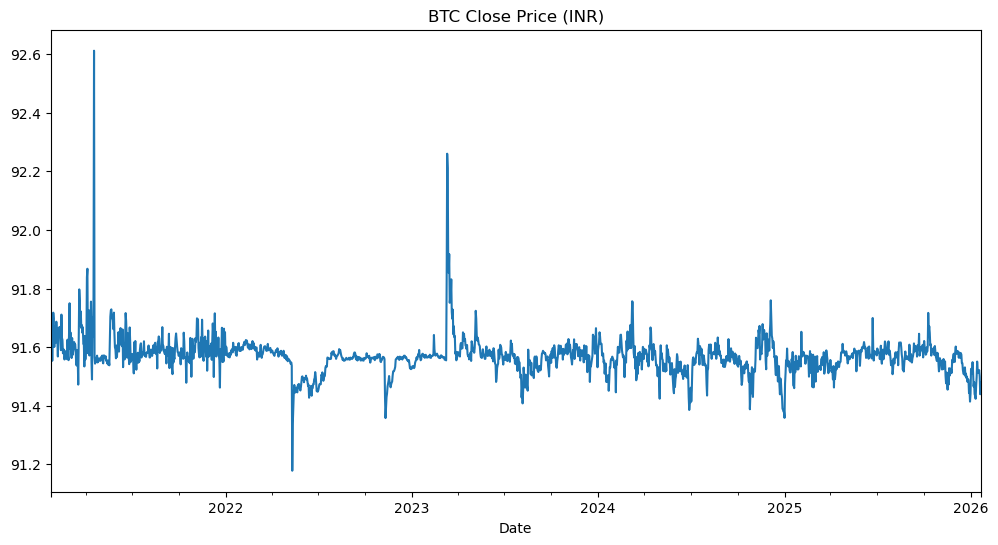

In [4]:
df['Close'].plot(figsize=(12,6), title='BTC Close Price (INR)')
plt.show()

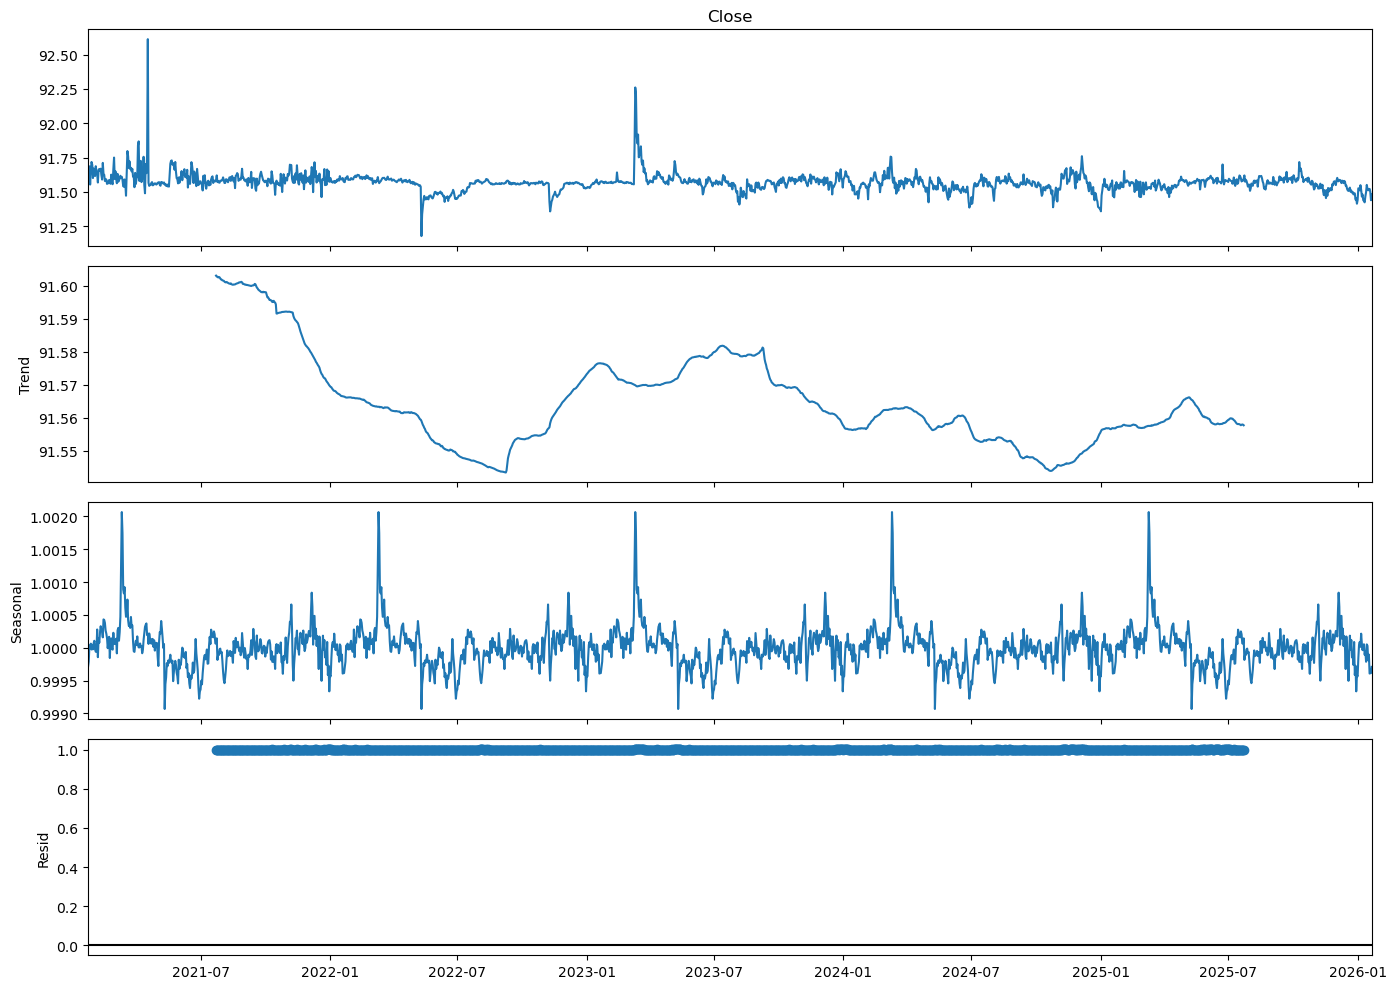

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# ensure daily frequency
df = df.asfreq('D')

# optional but recommended (prices > 0)
df['Close'] = df['Close'].interpolate()

result = seasonal_decompose(
    df['Close'],
    model='multiplicative',
    period=365
)
plt.rcParams['figure.figsize'] = (14, 10)
result.plot()
plt.show()


## Splitting data into 80% training data and 20% testing data

In [7]:
split_ratio = 0.8
split_index = int(len(df) * split_ratio)

train = df.iloc[:split_index]
test  = df.iloc[split_index:]

print(train.shape, test.shape)

(1460, 5) (366, 5)


## LSTM requires Min-Max Scaling or simple scaled features only

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

train_scaled = scaler.fit_transform(train[['Close']])
test_scaled  = scaler.transform(test[['Close']])

In [10]:
import numpy as np

n_input = 60          # use last 60 days
n_features = 1        # Close price only
batch_size = 32

In [11]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

train_generator = TimeseriesGenerator(
    train_scaled,
    train_scaled,
    length=n_input,
    batch_size=batch_size
)

test_generator = TimeseriesGenerator(
    test_scaled,
    test_scaled,
    length=n_input,
    batch_size=batch_size
)

In [12]:
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.optimizers import Adam

model = Sequential()
model.add(
    LSTM(
        100,
        activation='tanh',
        input_shape=(n_input, n_features)
    )
)
model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()

D:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100)                 │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    verbose=1
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0075 - val_loss: 7.3577e-04
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016 - val_loss: 4.4908e-04
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016 - val_loss: 6.3228e-04
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0016 - val_loss: 4.3939e-04
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015 - val_loss: 4.6027e-04
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0015 - val_loss: 5.1486e-04
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0015 - val_loss: 4.1300e-04
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0015 - val_loss: 5.1434e-04
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 4.0971e-04
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 4.9415e-04
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 4.3498e-04
Epoch 12/20
44/44 ━

In [14]:
predictions_scaled = model.predict(test_generator)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [15]:
predictions = scaler.inverse_transform(predictions_scaled)

In [16]:
actual = test['Close'].values[n_input:]

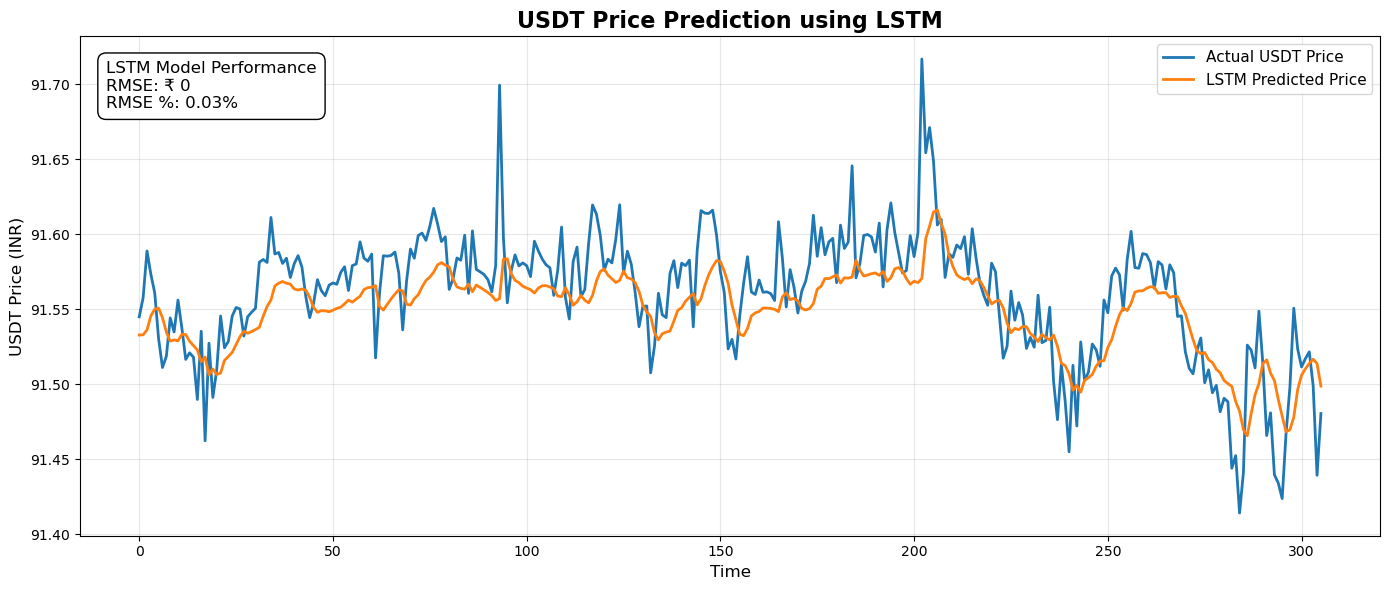

In [17]:
rmse = np.sqrt(mean_squared_error(actual, predictions))
rmse_percent = (rmse / np.mean(actual)) * 100

inr_rmse_on_fig = f"₹ {rmse:,.0f}"
percent_rmse_on_fig = f"{rmse_percent:.2f}%"

# --- PLOT ---
plt.figure(figsize=(14,6))

plt.plot(actual, label='Actual BTC Price', linewidth=2)
plt.plot(predictions.flatten(), label='LSTM Predicted Price', linewidth=2)

plt.title('BTC Price Prediction using LSTM', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('BTC Price (INR)', fontsize=12)

# 📦 METRICS BOX INSIDE GRAPH
metrics_text = f"LSTM Model Performance\nRMSE: {inr_rmse_on_fig}\nRMSE %: {percent_rmse_on_fig}"

plt.text(
    0.02, 0.95, metrics_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='black')
)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()

# 💾 HIGH RES SAVE
plt.savefig("BTC_LSTM_Prediction.png", dpi=300, bbox_inches='tight')

plt.show()